# Klasyfikacja ramek EKG: konwolucyjne warstwy falkowe

Notebook wykonuje klasyfikację ramek sygnału EKG z MIT-BIH na dwie klasy:
sygnał bez arytmii i sygnał z arytmią. Styl przygotowania danych i walidacji
jest zgodny z Lab7: segmenty są wycinane z lokalnych plików MIT-BIH, dane są
balansowane per rekord, a walidacja pilnuje, aby rekord/pacjent z części
testowej nie pojawiał się w treningu.

Różnica względem Lab7 jest celowa: wejściem sieci są ramki 1D EKG, a nie obrazy
CWT. Pierwsze warstwy są warstwami falkowymi, czyli stałymi konwolucjami 1D
filtrami dekompozycji falkowej. Porównane konfiguracje:

- jedna warstwa falkowa,
- dwie warstwy falkowe,
- jedna warstwa falkowa i jedna zwykła warstwa konwolucyjna.

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt

from IPython.display import display
from scipy.signal import correlate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd()
DATA_DIR = ROOT / "MIT-BIH" / "mitbih_database"
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Brak katalogu danych: {DATA_DIR}")

print(f"Katalog danych: {DATA_DIR}")
print(f"Liczba plików CSV: {len(list(DATA_DIR.glob('*.csv')))}")

Katalog danych: /home/ezdies/SignalsNeuralNetworks/Lab8/MIT-BIH/mitbih_database
Liczba plików CSV: 48


## Przygotowanie ramek EKG

MIT-BIH ma sygnały próbkowane z częstotliwością 360 Hz. Ramki są wycinane wokół
adnotowanych pobudzeń. Klasa `0` oznacza pobudzenia normalne według grupy AAMI
(`N`, `L`, `R`, `e`, `j`), a klasa `1` pozostałe pobudzenia traktowane jako
arytmia. Artefakty i adnotacje techniczne są pomijane.

Z każdego rekordu pobierana jest ograniczona, zbalansowana liczba ramek, aby
notebook liczył się szybko i aby rekordy z wieloma normalnymi pobudzeniami nie
zdominowały treningu.

In [2]:
FS = 360
WINDOW = 256
HALF_WINDOW = WINDOW // 2
NORMAL_SYMBOLS = {"N", "L", "R", "e", "j"}
EXCLUDED_SYMBOLS = {"+", "~", "|", "!", "[", "]", "x", "f", "Q", "?", '"'}
MAX_PER_CLASS_PER_RECORD = 24


def read_annotations(path: Path) -> pd.DataFrame:
    rows = []
    pattern = re.compile(r"^\s*(\S+)\s+(\d+)\s+(\S+)\s+")
    for line in path.read_text(errors="ignore").splitlines():
        match = pattern.match(line)
        if not match:
            continue
        _, sample, beat_type = match.groups()
        if beat_type in EXCLUDED_SYMBOLS:
            continue
        rows.append({"sample": int(sample), "type": beat_type})
    return pd.DataFrame(rows)


def zscore(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-8)


def load_frames(data_dir: Path) -> pd.DataFrame:
    records = []
    for csv_path in sorted(data_dir.glob("*.csv")):
        record_id = csv_path.stem
        ann_path = data_dir / f"{record_id}annotations.txt"
        if not ann_path.exists():
            continue

        signal_df = pd.read_csv(csv_path)
        signal_df.columns = [str(col).strip().strip("'\"") for col in signal_df.columns]
        channel = "MLII" if "MLII" in signal_df.columns else [col for col in signal_df.columns if col != "sample #"][0]
        signal = signal_df[channel].to_numpy(dtype=np.float32)
        annotations = read_annotations(ann_path)

        local = []
        for _, row in annotations.iterrows():
            center = int(row["sample"])
            start = center - HALF_WINDOW
            end = center + HALF_WINDOW
            if start < 0 or end > len(signal):
                continue
            label = 0 if row["type"] in NORMAL_SYMBOLS else 1
            local.append(
                {
                    "record": record_id,
                    "sample": center,
                    "symbol": row["type"],
                    "label": label,
                    "frame": zscore(signal[start:end]),
                }
            )

        if not local:
            continue
        local_df = pd.DataFrame(local)
        balanced_parts = []
        rng = np.random.default_rng(RANDOM_STATE + int(record_id))
        for label, group in local_df.groupby("label"):
            take = min(MAX_PER_CLASS_PER_RECORD, len(group))
            balanced_parts.append(group.sample(n=take, random_state=int(rng.integers(0, 1_000_000))))
        records.append(pd.concat(balanced_parts, ignore_index=True))

    if not records:
        raise RuntimeError("Nie znaleziono ramek EKG do analizy.")
    return pd.concat(records, ignore_index=True)


frames = load_frames(DATA_DIR)
X_frames = np.stack(frames["frame"].to_numpy()).astype(np.float32)
y = frames["label"].to_numpy(dtype=np.int64)
groups = frames["record"].to_numpy()

display(frames.drop(columns=["frame"]).head())
print("Liczba ramek:", len(frames))
print("Liczba rekordów/pacjentów:", frames["record"].nunique())
display(pd.crosstab(frames["record"], frames["label"], margins=True).rename(columns={0: "normal", 1: "arytmia"}))

,record,sample,symbol,label
0,100,118607,N,0
1,100,468459,N,0
2,100,431615,N,0
3,100,179388,N,0
4,100,476705,N,0


Liczba ramek: 1991
Liczba rekordów/pacjentów: 48


label,normal,arytmia,All
record,,,
100,24,24,48
101,24,3,27
102,24,24,48
103,24,2,26
104,24,24,48
105,24,24,48
106,24,24,48
107,0,24,24
108,24,23,47


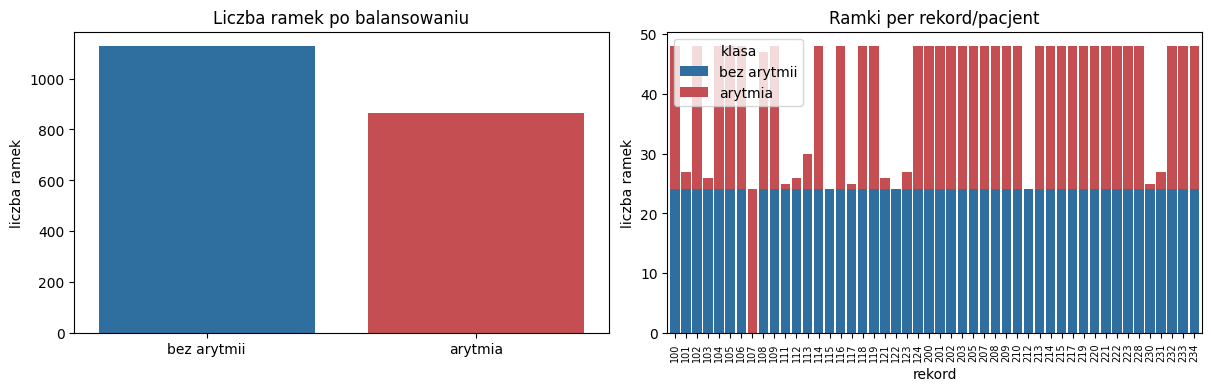

In [3]:
label_names = {0: "bez arytmii", 1: "arytmia"}
label_counts = frames["label"].map(label_names).value_counts().reindex(["bez arytmii", "arytmia"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
axes[0].bar(label_counts.index, label_counts.values, color=["#2f6f9f", "#c44e52"])
axes[0].set_title("Liczba ramek po balansowaniu")
axes[0].set_ylabel("liczba ramek")

per_record = pd.crosstab(frames["record"], frames["label"]).rename(columns=label_names)
per_record.plot(kind="bar", stacked=True, ax=axes[1], color=["#2f6f9f", "#c44e52"], width=0.85)
axes[1].set_title("Ramki per rekord/pacjent")
axes[1].set_xlabel("rekord")
axes[1].set_ylabel("liczba ramek")
axes[1].tick_params(axis="x", labelsize=7)
axes[1].legend(title="klasa")
plt.show()

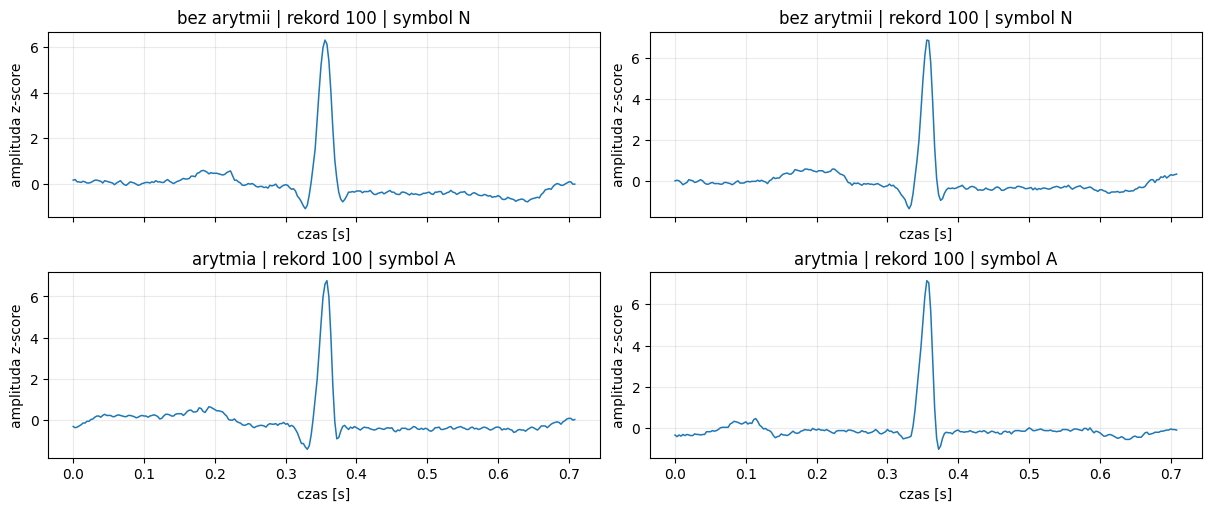

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5), constrained_layout=True, sharex=True)
time_axis = np.arange(WINDOW) / FS
for row, label in enumerate([0, 1]):
    examples = frames[frames["label"] == label].sort_values(["record", "sample"]).head(2)
    for col, (_, example) in enumerate(examples.iterrows()):
        axes[row, col].plot(time_axis, example["frame"], linewidth=1.1)
        axes[row, col].set_title(
            f"{label_names[label]} | rekord {example['record']} | symbol {example['symbol']}"
        )
        axes[row, col].set_xlabel("czas [s]")
        axes[row, col].set_ylabel("amplituda z-score")
        axes[row, col].grid(alpha=0.25)
plt.show()

## Warstwy falkowe jako konwolucje 1D

Warstwa falkowa używa filtrów dekompozycji wybranej falki (`db4`): dolnoprzepustowego
i górnoprzepustowego. Dla każdej ramki wykonywana jest konwolucja, aktywacja ReLU
i redukcja długości przez próbkowanie co drugi punkt. Druga warstwa falkowa działa
analogicznie na mapach cech z warstwy pierwszej.

Zwykła warstwa konwolucyjna w trzeciej konfiguracji używa losowo zainicjalizowanego
banku filtrów 1D. Końcowa warstwa klasyfikacyjna to regresja logistyczna trenowana
na cechach statystycznych z map konwolucyjnych.

In [5]:
def conv1d_same(x: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    return correlate(x, kernel, mode="same")


def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(x, 0)


def pool_stats(feature_maps: list[np.ndarray]) -> np.ndarray:
    features = []
    for fmap in feature_maps:
        fmap = np.asarray(fmap, dtype=np.float32)
        features.extend(
            [
                float(fmap.mean()),
                float(fmap.std()),
                float(fmap.max()),
                float(fmap.min()),
                float(np.percentile(fmap, 25)),
                float(np.percentile(fmap, 50)),
                float(np.percentile(fmap, 75)),
                float(np.mean(np.abs(fmap))),
            ]
        )
    return np.array(features, dtype=np.float32)


class WaveletLayer1D:
    def __init__(self, wavelet: str = "db4"):
        w = pywt.Wavelet(wavelet)
        self.wavelet = wavelet
        self.filters = [
            np.array(w.dec_lo[::-1], dtype=np.float32),
            np.array(w.dec_hi[::-1], dtype=np.float32),
        ]

    def transform_one(self, signals: list[np.ndarray]) -> list[np.ndarray]:
        out = []
        for signal in signals:
            for kernel in self.filters:
                fmap = relu(conv1d_same(signal, kernel))[::2]
                out.append(fmap.astype(np.float32))
        return out


class RandomConvLayer1D:
    def __init__(self, n_filters: int = 8, kernel_size: int = 9, random_state: int = 42):
        rng = np.random.default_rng(random_state)
        scale = np.sqrt(2 / kernel_size)
        self.filters = rng.normal(0, scale, size=(n_filters, kernel_size)).astype(np.float32)
        self.filters -= self.filters.mean(axis=1, keepdims=True)

    def transform_one(self, signals: list[np.ndarray]) -> list[np.ndarray]:
        out = []
        for signal in signals:
            for kernel in self.filters:
                out.append(relu(conv1d_same(signal, kernel)).astype(np.float32))
        return out


class WaveletConvECGNet:
    def __init__(
        self,
        architecture: str,
        wavelet: str = "db4",
        random_state: int = 42,
    ):
        self.architecture = architecture
        self.wavelet = wavelet
        self.random_state = random_state

    def _layers(self):
        layers = [WaveletLayer1D(self.wavelet)]
        if self.architecture == "2 warstwy falkowe":
            layers.append(WaveletLayer1D(self.wavelet))
        elif self.architecture == "1 falkowa + 1 konwolucyjna":
            layers.append(RandomConvLayer1D(n_filters=8, kernel_size=9, random_state=self.random_state))
        elif self.architecture != "1 warstwa falkowa":
            raise ValueError(f"Nieznana architektura: {self.architecture}")
        return layers

    def transform(self, X: np.ndarray) -> np.ndarray:
        layers = self._layers()
        rows = []
        for frame in X:
            maps = [frame.astype(np.float32)]
            for layer in layers:
                maps = layer.transform_one(maps)
            rows.append(pool_stats(maps))
        return np.vstack(rows).astype(np.float32)

    def fit(self, X: np.ndarray, y: np.ndarray):
        features = self.transform(X)
        self.classifier_ = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=800,
                class_weight="balanced",
                random_state=self.random_state,
            ),
        )
        self.classifier_.fit(features, y)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.classifier_.predict(self.transform(X))

In [6]:
ARCHITECTURES = [
    "1 warstwa falkowa",
    "2 warstwy falkowe",
    "1 falkowa + 1 konwolucyjna",
]
WAVELET = "db4"

preview_n = min(3, len(X_frames))
for arch in ARCHITECTURES:
    model = WaveletConvECGNet(architecture=arch, wavelet=WAVELET, random_state=RANDOM_STATE)
    features = model.transform(X_frames[:preview_n])
    print(f"{arch}: macierz cech dla {preview_n} ramek = {features.shape}")

1 warstwa falkowa: macierz cech dla 3 ramek = (3, 16)
2 warstwy falkowe: macierz cech dla 3 ramek = (3, 32)
1 falkowa + 1 konwolucyjna: macierz cech dla 3 ramek = (3, 128)


## Walidacja krzyżowa po pacjentach

Użyty jest `StratifiedGroupKFold`: etykiety są stratyfikowane, ale grupą jest
rekord/pacjent. Dla każdego foldu sprawdzany jest warunek rozłączności grup
treningowych i testowych. Raportowane metryki to accuracy, macro precision,
macro recall, macro F1 i średnie bezwzględne MCC.

In [7]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def normalize_frames_by_train(X: np.ndarray, train_idx: np.ndarray, test_idx: np.ndarray):
    mean = X[train_idx].mean()
    std = X[train_idx].std() + 1e-8
    return (X[train_idx] - mean) / std, (X[test_idx] - mean) / std


def evaluate_architecture(architecture: str):
    fold_rows = []
    confusion_sum = np.zeros((2, 2), dtype=int)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_frames, y, groups=groups), start=1):
        train_groups = set(groups[train_idx])
        test_groups = set(groups[test_idx])
        assert train_groups.isdisjoint(test_groups)

        X_train, X_test = normalize_frames_by_train(X_frames, train_idx, test_idx)
        clf = WaveletConvECGNet(
            architecture=architecture,
            wavelet=WAVELET,
            random_state=RANDOM_STATE + fold,
        )
        clf.fit(X_train, y[train_idx])
        pred = clf.predict(X_test)

        row = {
            "architecture": architecture,
            "fold": fold,
            "train_records": len(train_groups),
            "test_records": len(test_groups),
            "test_samples": len(test_idx),
            "accuracy": accuracy_score(y[test_idx], pred),
            "precision_macro": precision_score(y[test_idx], pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y[test_idx], pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y[test_idx], pred, average="macro", zero_division=0),
            "mcc_abs": abs(matthews_corrcoef(y[test_idx], pred)),
        }
        fold_rows.append(row)
        confusion_sum += confusion_matrix(y[test_idx], pred, labels=[0, 1])
        print(
            f"{architecture}, fold {fold}: "
            f"acc={row['accuracy']:.3f}, f1={row['f1_macro']:.3f}, "
            f"|MCC|={row['mcc_abs']:.3f}, test records={sorted(test_groups)}"
        )
    return pd.DataFrame(fold_rows), confusion_sum


all_results = []
confusion_by_architecture = {}
for architecture in ARCHITECTURES:
    fold_df, cm = evaluate_architecture(architecture)
    all_results.append(fold_df)
    confusion_by_architecture[architecture] = cm

results = pd.concat(all_results, ignore_index=True)
display(results)

1 warstwa falkowa, fold 1: acc=0.646, f1=0.643, |MCC|=0.294, test records=['111', '118', '202', '207', '212', '214', '222', '223', '231', '233']


1 warstwa falkowa, fold 2: acc=0.646, f1=0.610, |MCC|=0.250, test records=['100', '102', '106', '121', '122', '123', '124', '203', '220', '232']


1 warstwa falkowa, fold 3: acc=0.784, f1=0.784, |MCC|=0.568, test records=['101', '104', '105', '107', '114', '117', '200', '205', '208', '228']


1 warstwa falkowa, fold 4: acc=0.812, f1=0.812, |MCC|=0.646, test records=['103', '113', '115', '116', '119', '201', '210', '217', '221']


1 warstwa falkowa, fold 5: acc=0.554, f1=0.553, |MCC|=0.110, test records=['108', '109', '112', '209', '213', '215', '219', '230', '234']


...

1 falkowa + 1 konwolucyjna, fold 2: acc=0.746, f1=0.719, |MCC|=0.476, test records=['100', '102', '106', '121', '122', '123', '124', '203', '220', '232']


1 falkowa + 1 konwolucyjna, fold 3: acc=0.745, f1=0.745, |MCC|=0.498, test records=['101', '104', '105', '107', '114', '117', '200', '205', '208', '228']


1 falkowa + 1 konwolucyjna, fold 4: acc=0.902, f1=0.900, |MCC|=0.799, test records=['103', '113', '115', '116', '119', '201', '210', '217', '221']


1 falkowa + 1 konwolucyjna, fold 5: acc=0.617, f1=0.614, |MCC|=0.228, test records=['108', '109', '112', '209', '213', '215', '219', '230', '234']


,architecture,fold,train_records,test_records,test_samples,accuracy,precision_macro,recall_macro,f1_macro,mcc_abs
0,1 warstwa falkowa,1,38,10,412,0.645631,0.644844,0.648886,0.642905,0.293701
1,1 warstwa falkowa,2,38,10,413,0.646489,0.638068,0.612729,0.609570,0.249513
2,1 warstwa falkowa,3,38,10,412,0.783981,0.783559,0.784061,0.783694,0.567619
3,1 warstwa falkowa,4,39,9,368,0.812500,0.818838,0.827607,0.811887,0.646386
4,1 warstwa falkowa,5,39,9,386,0.554404,0.554714,0.555501,0.552952,0.110213
5,2 warstwy falkowe,1,38,10,412,0.677184,0.667391,0.665262,0.666120,0.332645
6,2 warstwy falkowe,2,38,10,413,0.707022,0.716367,0.673687,0.674801,0.387712
7,2 warstwy falkowe,3,38,10,412,0.798544,0.798253,0.798895,0.798343,0.597148
8,2 warstwy falkowe,4,39,9,368,0.812500,0.817513,0.826633,0.811765,0.644081
9,2 warstwy falkowe,5,39,9,386,0.580311,0.583980,0.584913,0.579905,0.168890


In [8]:
metric_cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "mcc_abs"]
summary = results.groupby("architecture")[metric_cols].agg(["mean", "std"]).round(4)
display(summary)

ranking = results.groupby("architecture")[metric_cols].mean().sort_values("f1_macro", ascending=False).round(4)
display(ranking)
print(f"Najlepsza konfiguracja wg średniego F1 macro: {ranking.index[0]}")

accuracy         precision_macro          \
                               mean     std            mean     std   
architecture                                                          
1 falkowa + 1 konwolucyjna   0.7170  0.1285          0.7245  0.1235   
1 warstwa falkowa            0.6886  0.1073          0.6880  0.1100   
2 warstwy falkowe            0.7151  0.0950          0.7167  0.0960   

                           recall_macro         f1_macro         mcc_abs  \
                                   mean     std     mean     std    mean   
architecture                                                               
1 falkowa + 1 konwolucyjna       0.7147  0.1226   0.7104  0.1272  0.4387   
1 warstwa falkowa                0.6858  0.1156   0.6802  0.1125  0.3735   
2 warstwy falkowe                0.7099  0.1006   0.7062  0.0977  0.4261   

                                    
                               std  
architecture                        
1 falkowa + 1 konwolucyjna  0.2450  
1 warstwa falkowa           0.2254  
2 warstwy falkowe           0.1957

,accuracy,precision_macro,recall_macro,f1_macro,mcc_abs
architecture,,,,,
1 falkowa + 1 konwolucyjna,0.7170,0.7245,0.7147,0.7104,0.4387
2 warstwy falkowe,0.7151,0.7167,0.7099,0.7062,0.4261
1 warstwa falkowa,0.6886,0.6880,0.6858,0.6802,0.3735


Najlepsza konfiguracja wg średniego F1 macro: 1 falkowa + 1 konwolucyjna


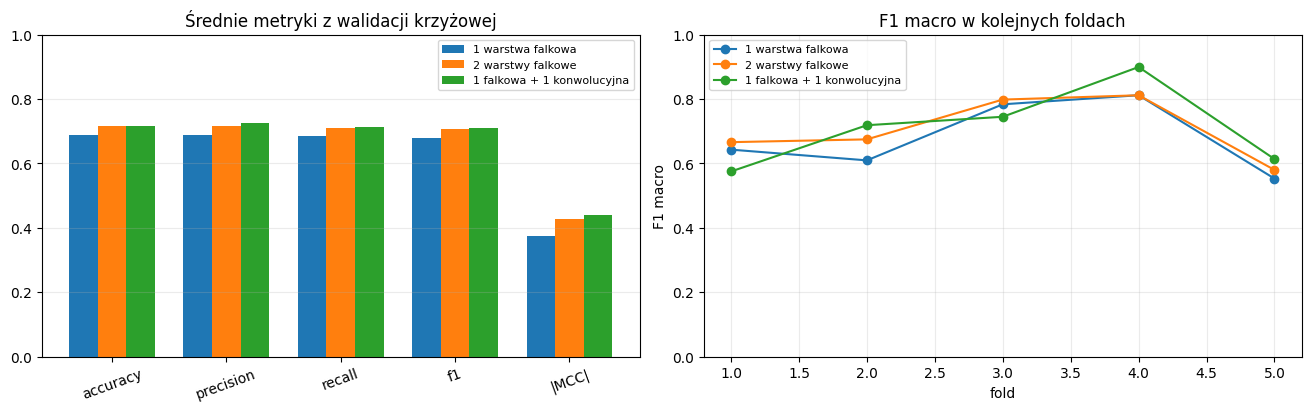

In [9]:
plot_summary = results.groupby("architecture")[metric_cols].mean().loc[ARCHITECTURES]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
x = np.arange(len(metric_cols))
width = 0.25
for idx, architecture in enumerate(ARCHITECTURES):
    values = plot_summary.loc[architecture, metric_cols].to_numpy()
    axes[0].bar(x + (idx - 1) * width, values, width=width, label=architecture)
axes[0].set_title("Średnie metryki z walidacji krzyżowej")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["accuracy", "precision", "recall", "f1", "|MCC|"], rotation=20)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.25)

fold_metric = results.pivot(index="fold", columns="architecture", values="f1_macro")
fold_metric[ARCHITECTURES].plot(ax=axes[1], marker="o")
axes[1].set_title("F1 macro w kolejnych foldach")
axes[1].set_xlabel("fold")
axes[1].set_ylabel("F1 macro")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
plt.show()

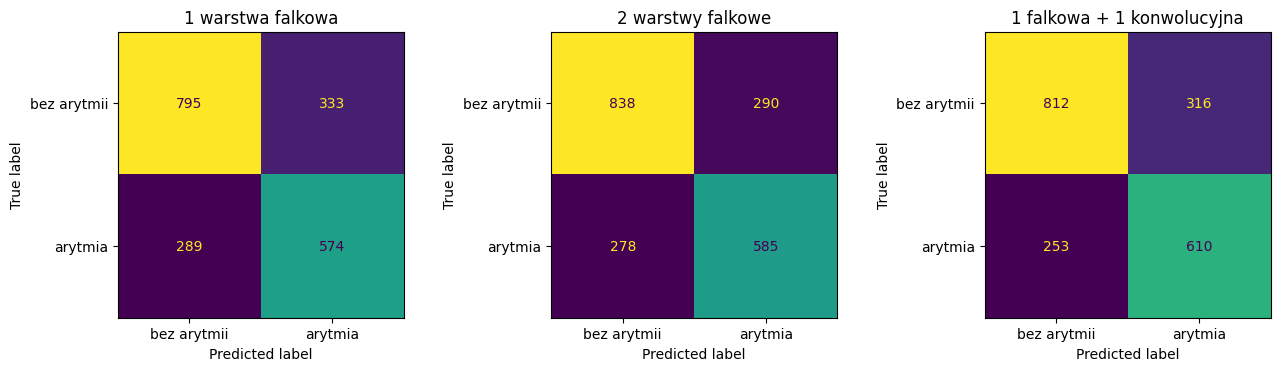

In [10]:
fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(13, 3.6), constrained_layout=True)
for ax, architecture in zip(axes, ARCHITECTURES):
    disp = ConfusionMatrixDisplay(
        confusion_by_architecture[architecture],
        display_labels=["bez arytmii", "arytmia"],
    )
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(architecture)
plt.show()

## Wnioski

Notebook porównuje trzy konfiguracje sieci konwolucyjnych z warstwami falkowymi
na ramkach 1D EKG. Walidacja jest grupowana po rekordzie/pacjencie, więc ten sam
pacjent nie trafia jednocześnie do treningu i testu. Wyniki końcowe należy czytać
z tabel `summary` i `ranking` powyżej: zawierają średnie oraz odchylenia standardowe
dla accuracy, precision, recall, F1 oraz średniego bezwzględnego MCC.

Najbardziej wymagającą metryką jest MCC, bo uwzględnia wszystkie pola macierzy
pomyłek. W tym zadaniu raportowane jest `abs(MCC)` zgodnie z wymaganiem, a makro
uśrednianie precision/recall/F1 ogranicza wpływ ewentualnej nierównowagi klas w
poszczególnych foldach.